# Lab 3 — DBSCAN Clusters and Noise

**Day 05 · Unsupervised Learning · Cisco AI/ML Training**

---

Use density clustering to detect core clusters and noisy outlier symbols.

**Dataset:** `data/nyse/nyse_stocks.csv` (500 rows, 25 symbols)

## Why this matters <!-- cisco-doc-enrich-2026 -->

**DBSCAN** finds arbitrary shapes and labels **noise** — useful when some NYSE symbols do not
belong to any clean sector cluster.

```
dense region  ===>  cluster
sparse point  ===>  noise (-1)
eps + min_samples control sensitivity
```


## Syllabus note — Spectral & OPTICS

The course also mentions **Spectral Clustering** and **OPTICS**. This notebook keeps the original comparison section.

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

FEATURE_COLUMNS = ["avg_close", "volatility", "avg_volume", "avg_range"]

**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
nyse = pd.read_csv(GH_ROOT / "data" / "nyse" / "nyse_stocks.csv", parse_dates=["date"])
nyse["range"] = nyse["high"] - nyse["low"]
features = (
    nyse.groupby("symbol")
    .agg(
        avg_close=("close", "mean"),
        volatility=("close", "std"),
        avg_volume=("volume", "mean"),
        avg_range=("range", "mean"),
    )
    .reset_index()
)
features["volatility"] = features["volatility"].fillna(0.0)

X_scaled = StandardScaler().fit_transform(features[FEATURE_COLUMNS])
print(f"symbols: {len(features)}")

symbols: 25


## Fit DBSCAN

In [4]:
EPS = 1.2
MIN_SAMPLES = 3

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

unique, counts = np.unique(labels, return_counts=True)
label_counts = dict(zip(unique.tolist(), counts.tolist()))

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [5]:
print("Lab 3 — DBSCAN clusters")
print(f"eps: {EPS}, min_samples: {MIN_SAMPLES}")
print(f"clusters found: {n_clusters}")
print(f"noise points: {n_noise}")
print(f"label counts: {label_counts}")

Lab 3 — DBSCAN clusters
eps: 1.2, min_samples: 3
clusters found: 3
noise points: 11
label counts: {-1: 11, 0: 6, 1: 4, 2: 4}


## 2b. Compare Spectral & OPTICS (course topic)

In [6]:
from sklearn.cluster import OPTICS, SpectralClustering

def cluster_summary(name: str, lbl: np.ndarray) -> None:
    noise = int(np.sum(lbl == -1))
    clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    print(f"{name:18s} clusters={clusters}, noise={noise}")

spec_labels = SpectralClustering(
    n_clusters=3, affinity="nearest_neighbors", n_neighbors=5, random_state=42
).fit_predict(X_scaled)
optics_labels = OPTICS(min_samples=MIN_SAMPLES).fit_predict(X_scaled)

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [7]:
cluster_summary("DBSCAN", labels)
cluster_summary("Spectral (k=3)", spec_labels)
cluster_summary("OPTICS", optics_labels)
print("Spectral: graph-based — good for non-convex groups.")
print("OPTICS: ordering by density — reveals varying-density hierarchies.")

DBSCAN             clusters=3, noise=11
Spectral (k=3)     clusters=3, noise=0
OPTICS             clusters=3, noise=13
Spectral: graph-based — good for non-convex groups.
OPTICS: ordering by density — reveals varying-density hierarchies.


## Attach labels to feature table

In [8]:
features = features.copy()
features["dbscan_label"] = labels

display(
    features[["symbol", "avg_close", "volatility", "dbscan_label"]]
    .sort_values("dbscan_label")
    .round(2)
)


,symbol,avg_close,volatility,dbscan_label
0,AAPL,186.88,2.23,-1
1,AMZN,52.76,2.61,-1
5,GOOGL,122.58,3.31,-1
4,DIS,203.29,2.49,-1
13,MSFT,215.09,3.11,-1
14,NFLX,220.97,2.68,-1
11,MA,93.21,2.12,-1
16,PEP,232.55,1.63,-1
24,XOM,70.84,2.84,-1
21,V,247.82,2.81,-1


## Visualize DBSCAN labels

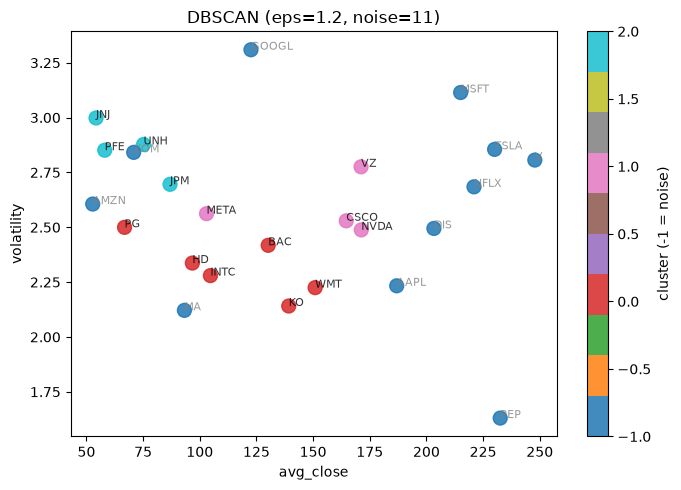

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    features["avg_close"],
    features["volatility"],
    c=features["dbscan_label"],
    cmap="tab10",
    s=100,
    alpha=0.85,
)
for _, row in features.iterrows():
    color = "gray" if row["dbscan_label"] == -1 else "black"
    ax.annotate(row["symbol"], (row["avg_close"], row["volatility"]), fontsize=8, color=color, alpha=0.8)
ax.set_xlabel("avg_close")
ax.set_ylabel("volatility")
ax.set_title(f"DBSCAN (eps={EPS}, noise={n_noise})")
fig.colorbar(scatter, ax=ax, label="cluster (-1 = noise)")
plt.tight_layout()
plt.show()


## Compare with K-Means cluster counts

In [10]:
kmeans_labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)
kmeans_counts = dict(zip(*np.unique(kmeans_labels, return_counts=True)))

compare = pd.DataFrame({
    "method": ["K-Means (k=4)", "DBSCAN"],
    "clusters": [4, n_clusters],
    "noise_or_unassigned": [0, n_noise],
    "label_counts": [str(kmeans_counts), str(label_counts)],
})
display(compare)


,method,clusters,noise_or_unassigned,label_counts
0,K-Means (k=4),4,0,"{np.int32(0): np.int64(8), np.int32(1): np.int..."
1,DBSCAN,3,11,"{-1: 11, 0: 6, 1: 4, 2: 4}"


## Sensitivity study for epsilon

In [11]:
rows = []
for eps in [0.8, 1.2, 1.5]:
    lbl = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_scaled)
    n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_no = int(np.sum(lbl == -1))
    rows.append({"eps": eps, "clusters": n_clust, "noise": n_no})

display(pd.DataFrame(rows))


,eps,clusters,noise
0,0.8,0,25
1,1.2,3,11
2,1.5,1,8


### Density clustering prompt 1

Show the noise symbols list.

In [12]:
display(features.loc[features['dbscan_label']==-1, ['symbol','avg_close','volatility']].round(2))

,symbol,avg_close,volatility
0,AAPL,186.88,2.23
1,AMZN,52.76,2.61
4,DIS,203.29,2.49
5,GOOGL,122.58,3.31
11,MA,93.21,2.12
13,MSFT,215.09,3.11
14,NFLX,220.97,2.68
16,PEP,232.55,1.63
19,TSLA,230.07,2.86
21,V,247.82,2.81


### Density clustering prompt 2

Count non-noise symbols.

In [13]:
print(int((features['dbscan_label']!=-1).sum()))

14


### Density clustering prompt 3

Compute mean volatility among noise points.

In [14]:
print(round(features.loc[features['dbscan_label']==-1, 'volatility'].mean(), 3))

2.609


### Density clustering prompt 4

Compute mean avg_close among clustered points.

In [15]:
print(round(features.loc[features['dbscan_label']!=-1, 'avg_close'].mean(), 2))

112.35


### Density clustering prompt 5

Sort label counts by key.

In [16]:
print(dict(sorted(label_counts.items(), key=lambda x: x[0])))

{-1: 11, 0: 6, 1: 4, 2: 4}


### Density clustering prompt 6

Cross-check DBSCAN clusters count formula.

In [17]:
print(len(set(labels)) - (1 if -1 in labels else 0))

3


### Density clustering prompt 7

Try a stricter min_samples quickly.

In [18]:
labels_ms4 = DBSCAN(eps=EPS, min_samples=4).fit_predict(X_scaled); print(dict(zip(*np.unique(labels_ms4, return_counts=True))))

{np.int64(-1): np.int64(15), np.int64(0): np.int64(6), np.int64(1): np.int64(4)}


### Density clustering prompt 8

Inspect symbols from cluster 0.

In [19]:
display(features.loc[features['dbscan_label']==0, ['symbol','avg_close','volatility']].round(2))

,symbol,avg_close,volatility
2,BAC,130.19,2.42
6,HD,96.71,2.34
7,INTC,104.69,2.28
10,KO,139.24,2.14
18,PG,66.80,2.50
23,WMT,150.89,2.22


### Density clustering prompt 9

Inspect symbols from cluster 1.

In [20]:
display(features.loc[features['dbscan_label']==1, ['symbol','avg_close','volatility']].round(2))

,symbol,avg_close,volatility
3,CSCO,164.62,2.53
12,META,102.98,2.56
15,NVDA,171.25,2.49
22,VZ,171.15,2.78


### Density clustering prompt 10

Inspect symbols from cluster 2.

In [21]:
display(features.loc[features['dbscan_label']==2, ['symbol','avg_close','volatility']].round(2))

,symbol,avg_close,volatility
8,JNJ,54.23,3.00
9,JPM,86.88,2.70
17,PFE,58.06,2.85
20,UNH,75.19,2.88


### Density clustering prompt 11

Compare kmeans vs dbscan assignment for first 10 symbols.

In [22]:
cmp = features[['symbol','dbscan_label']].copy(); cmp['kmeans_label']=kmeans_labels; display(cmp.head(10))

,symbol,dbscan_label,kmeans_label
0,AAPL,-1,1
1,AMZN,-1,1
2,BAC,0,1
3,CSCO,1,0
4,DIS,-1,0
5,GOOGL,-1,2
6,HD,0,1
7,INTC,0,1
8,JNJ,2,2
9,JPM,2,2


### Density clustering prompt 12

Compute agreement where DBSCAN is not noise.

In [23]:
tmp = features.copy(); tmp['kmeans']=kmeans_labels; mask = tmp['dbscan_label']!=-1; print(round((tmp.loc[mask,'dbscan_label']==tmp.loc[mask,'kmeans']).mean(), 3))

0.286


### Density clustering prompt 13

Show spread stats by dbscan label.

In [24]:
display(features.groupby('dbscan_label')[FEATURE_COLUMNS].agg(['mean','std']).round(2))

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

avg_close        volatility         avg_volume              \
                  mean    std       mean   std         mean         std   
dbscan_label                                                              
-1              170.55  71.64       2.61  0.47  24537715.07  3376887.51   
 0              114.75  31.21       2.32  0.13  27094811.46  2163408.92   
 1              152.50  33.16       2.59  0.13  22804049.69  1513449.07   
 2               68.59  15.22       2.86  0.12  26425986.24  1230793.91   

             avg_range        
                  mean   std  
dbscan_label                  
-1                2.83  0.34  
 0                2.73  0.13  
 1                3.02  0.07  
 2                3.03  0.19

Groupby complete — compare categories in the table above.


### Density clustering prompt 14

Check cluster_summary helper again.

In [25]:
cluster_summary('DBSCAN repeat', labels)

DBSCAN repeat      clusters=3, noise=11


### Density clustering prompt 15

Count labels with pandas.

In [26]:
print(features['dbscan_label'].value_counts().sort_index().to_dict())

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

{-1: 11, 0: 6, 1: 4, 2: 4}
Value counts — long tail categories may be omitted.


### Density clustering prompt 16

Display label histogram.

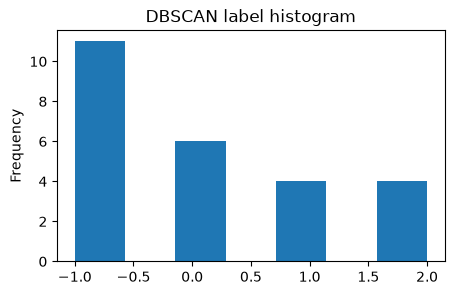

In [27]:
ax = features['dbscan_label'].plot(kind='hist', bins=7, figsize=(5,3)); ax.set_title('DBSCAN label histogram');

### Density clustering prompt 17

Summarize current parameters.

In [28]:
print({'EPS': EPS, 'MIN_SAMPLES': MIN_SAMPLES, 'n_clusters': n_clusters, 'n_noise': n_noise})

{'EPS': 1.2, 'MIN_SAMPLES': 3, 'n_clusters': 3, 'n_noise': 11}


### Density clustering prompt 18

Bridge to cluster metrics lab.

In [29]:
print('Next: evaluate cluster quality with silhouette, DB, and CH scores.')

Next: evaluate cluster quality with silhouette, DB, and CH scores.


### Density clustering prompt 19

Verify expected symbol count.

In [30]:
print(len(features), features['symbol'].nunique())

25 25


### Density clustering prompt 20

Review top 5 highest-volatility symbols.

In [31]:
display(features.nlargest(5, 'volatility')[['symbol','volatility','dbscan_label']].round(3))

,symbol,volatility,dbscan_label
5,GOOGL,3.309,-1
13,MSFT,3.114,-1
8,JNJ,2.998,2
20,UNH,2.877,2
19,TSLA,2.855,-1


### Lab 3 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 3 recap step 1: completed")

Lab 3 recap step 1: completed


### Lab 3 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 3 recap step 2: completed")

Lab 3 recap step 2: completed


### Lab 3 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

In [34]:
print("Lab 3 recap step 3: completed")

Lab 3 recap step 3: completed


## Final checkpoint

In [35]:
assert len(features) == 25
assert n_clusters == 3
assert n_noise == 11
assert label_counts[-1] == 11
assert label_counts[0] == 6 and label_counts[1] == 4 and label_counts[2] == 4
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

Why is explicit noise labeling useful for market anomaly watchlists?